In [69]:
from pathlib import Path
import sys
import os

%load_ext autoreload
%autoreload 2

dir = Path().resolve().parents[1]

if dir not in sys.path:
    print("directory path is not in the system path")
    sys.path.append(str(dir))
    print("adding directory...")
else:
    print("Directory already exists in the system path")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
directory path is not in the system path
adding directory...


In [70]:
from nn import Unet1D, Returns, RMSELoss, EarlyStopping
from scripts import train, evaluate
from utils import log_transform
import torch
from torch.utils.data import DataLoader
import yfinance as yf
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

In [71]:
ticker = "^GSPC"
start_interval = "2016-12-01"
end_interval = "2026-01-01"
interval = "1d"

raw_snp500 = torch.tensor(yf.Ticker(ticker).history(start=start_interval, end=end_interval, interval=interval)["Close"].to_numpy())

In [72]:
len(raw_snp500)

2283

In [73]:
raw_snp500[0:10]

tensor([2191.0801, 2191.9500, 2204.7100, 2212.2300, 2241.3501, 2246.1899,
        2259.5300, 2256.9600, 2271.7200, 2253.2800], dtype=torch.float64)

In [ ]:
split = math.ceil(len(raw_snp500) * 0.2)
val_split = len(raw_snp500) - split * 2
test_split = len(raw_snp500) - split
train_raw_snp500, val_raw_snp500, test_raw_snp500 = raw_snp500[:val_split], raw_snp500[val_split:test_split], raw_snp500[test_split:]

window_size = 256

train_data = Returns(
  raw_returns=train_raw_snp500,
  window_size=window_size,
  transform=log_transform,
  standard=True
)
val_data = Returns(
  raw_returns=val_raw_snp500,
  window_size=window_size,
  transform=log_transform,
  standard=True
)
test_data = Returns(
  raw_returns=test_raw_snp500,
  window_size=window_size,
  transform=log_transform,
  standard=True
)

len(train_data), len(val_data), len(test_data)

(1113, 201, 201)

In [75]:
train_data[100]

tensor([[-0.1914,  0.1049,  0.0608, -0.1392,  0.0115,  0.2959, -0.0327, -0.1191,
          0.0561, -0.2118, -0.1560,  0.3515, -0.0916, -1.5268,  0.2633,  0.5124,
          0.3825,  0.1135,  0.1663,  0.3245, -0.0105, -0.1337, -0.0732,  0.5773,
          0.2650, -0.1348, -0.2620,  0.0916, -0.0141, -0.1033, -0.1154,  0.3301,
         -0.1168, -0.2180, -0.0127,  0.6399, -0.5819, -0.0831, -0.0728,  0.0910,
         -0.0101, -0.6946,  0.6770, -0.7378,  0.0887,  0.1518,  0.0823, -0.8008,
          0.4830,  0.0396, -0.0994,  0.5558,  0.1164,  0.3432, -0.0401,  0.0128,
          0.3997, -0.0483, -0.0657, -0.1223,  0.2015, -0.0128, -0.1149, -0.1449,
         -0.0950,  0.1630,  0.0043, -0.2135,  0.1176,  0.0980, -0.2323, -0.0653,
         -1.2208,  0.0678,  0.7765, -0.0763,  0.0796, -1.3002, -0.1851,  0.0587,
          0.7682, -0.3170, -0.2046,  0.1001,  0.0038,  0.0327,  0.3385,  0.4279,
          0.1252, -0.6518,  0.2181, -0.0503, -0.1569,  0.8405,  0.2372,  0.0257,
         -0.1253,  0.1142,  

In [76]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True, drop_last=True)

next(iter(train_dataloader)).size()

torch.Size([32, 1, 256])

In [77]:
len(train_dataloader.dataset)

1113

In [78]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
torch.cuda.manual_seed(42)
device

'cpu'

In [79]:
betas = torch.linspace(1e-4, 2e-2, 1000)
type(1 - betas)

torch.Tensor

In [80]:
encoder_in_channels = [1, 4, 8, 16]
encoder_out_channels = [4, 8, 16, 32]
decoder_in_channels = [32, 16, 8, 4]
decoder_out_channels = [16, 8, 4, 1]
attn_res = 16
n_res_block = 2
T = 1000
num_heads = 4
betas = torch.linspace(1e-4, 2e-2, T)
alpha_hats = torch.cumprod(
  input=1-betas,
  dim=0,
  dtype=torch.float32
)

model = Unet1D(
  attn_res=attn_res,
  n_res_block=n_res_block,
  encoder_in_channels=encoder_in_channels,
  encoder_out_channels=encoder_out_channels,
  decoder_in_channels=decoder_in_channels,
  decoder_out_channels=decoder_out_channels,
  T=T,
  num_heads=num_heads
)

In [81]:
dir = Path().resolve().parents[1]
save_path = dir / "models"


In [82]:
loss_fn = RMSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
  optimizer=optimizer,
  mode='min',
  factor=0.4,
  patience=2,
  threshold=1e-4
)

early_stop = EarlyStopping(
  model=model,
  save_path=save_path,
  patience=10,
  delta=0,
  file_name="model_v0.pth",
  verbose=True
)

In [83]:
train_result = train(
  train_data=train_dataloader,
  val_data=val_dataloader,
  optimizer=optimizer,
  loss_fn=loss_fn,
  epochs=100,
  alpha_hats=alpha_hats,
  model=model,
  scheduler=scheduler,
  early_stopping=early_stop,
  device=device,
  T=T
)

  1%|          | 1/100 [00:03<05:21,  3.25s/it]

Epoch : 0 | train_loss : 1.11 | val_loss : 1.03
New best model found. Current loss: 1.0256173610687256
Current LR:  [0.001]


  2%|▏         | 2/100 [00:05<04:26,  2.72s/it]

Epoch : 1 | train_loss : 0.97 | val_loss : 0.90
New best model found. Current loss: 0.897807389497757
Current LR:  [0.001]


  3%|▎         | 3/100 [00:07<04:06,  2.54s/it]

...

Epoch : 38 | train_loss : 0.53 | val_loss : 0.57
Current LR:  [4.096000000000002e-06]


 40%|████      | 40/100 [01:38<02:51,  2.86s/it]

Epoch : 39 | train_loss : 0.52 | val_loss : 0.55
Current LR:  [1.638400000000001e-06]


 40%|████      | 40/100 [01:41<02:31,  2.53s/it]

Epoch : 40 | train_loss : 0.52 | val_loss : 0.54
Stopping early as no improvement has been observed
Best Loss 0.4952019651730855
Overwriting an existing model...
The best model has been saved
Early stopping at epoch : 40
Total training time: 101.25288581848145 seconds


In [84]:
test_result = evaluate(
  test_dataloader,
  loss_fn=loss_fn,
  model=model,
  alpha_hats=alpha_hats,
  T=T,
  device=device
)
test_result

0.5562410751978556

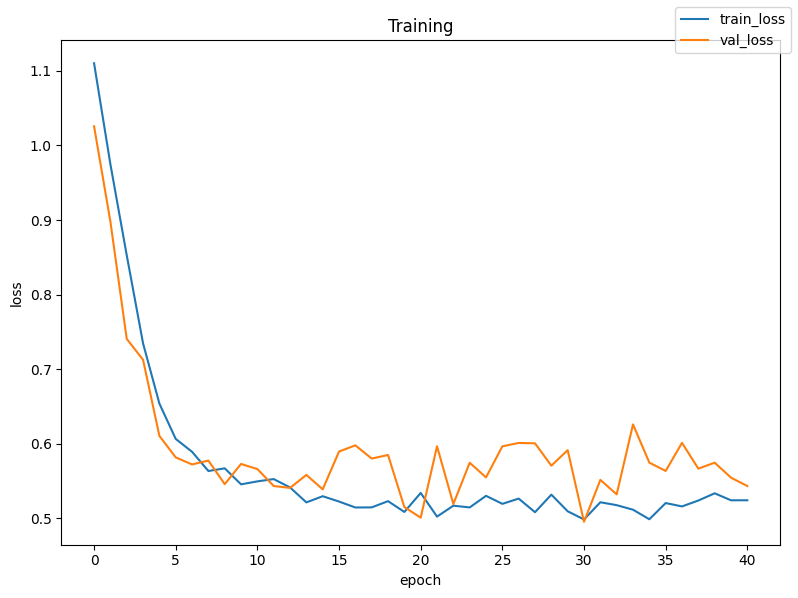

In [85]:
n_epochs = np.arange(0, len(train_result["train_loss"]))

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(n_epochs, train_result["train_loss"], label="train_loss")
ax.plot(n_epochs, train_result["val_loss"], label="val_loss")
# ax.set_xticks(n_epochs)

ax.set_title("Training")
ax.set_ylabel("loss")
ax.set_xlabel("epoch")
fig.legend()

plt.tight_layout()
plt.show()